# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Impact of Social Media on Life Dataset](https://www.kaggle.com/datasets/harishyadav0506/impact-of-social-media-on-life)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('Social_media_impact_on_life.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


## last Five row

In [4]:
df.tail()

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
4495,STU_2028495,16,Male,High School,YouTube,5.8,1.2,Smartphone,7.8,3,True,Sometimes,11.0,79,2.85,Beneficial
4496,STU_2028496,19,Female,Undergraduate,LinkedIn,3.8,3.0,Smartphone,6.6,3,False,Frequently,9.0,83,3.37,Beneficial
4497,STU_2028497,19,Male,Undergraduate,Instagram,7.7,1.1,Smartphone,6.0,2,True,Frequently,13.0,73,3.16,Beneficial
4498,STU_2028498,16,Male,High School,LinkedIn,4.6,3.3,Laptop/PC,7.1,3,False,Sometimes,22.0,87,3.50,Beneficial
4499,STU_2028499,24,Male,Undergraduate,Instagram,1.8,2.1,Smartphone,6.8,3,True,Frequently,10.0,98,3.73,Beneficial


## Shape of our dataset

In [5]:
df.shape

(4500, 16)

## List out all columns

In [6]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Primary_Platform',
       'Daily_Usage_Hours', 'Weekend_Extra_Hours', 'Device_Type',
       'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Late_Night_Usage',
       'Social_Comparison_Frequency', 'Perceived_Stress_Score',
       'Mental_Health_Index', 'Academic_Performance_GPA', 'Overall_Impact'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Student_ID                      object
Age                              int64
Gender                          object
Academic_Level                  object
Primary_Platform                object
Daily_Usage_Hours              float64
Weekend_Extra_Hours            float64
Device_Type                     object
Sleep_Duration_Hours           float64
Sleep_Quality_Score              int64
Late_Night_Usage                  bool
Social_Comparison_Frequency     object
Perceived_Stress_Score         float64
Mental_Health_Index              int64
Academic_Performance_GPA       float64
Overall_Impact                  object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   4500 non-null   object 
 1   Age                          4500 non-null   int64  
 2   Gender                       4500 non-null   object 
 3   Academic_Level               4500 non-null   object 
 4   Primary_Platform             4500 non-null   object 
 5   Daily_Usage_Hours            4500 non-null   float64
 6   Weekend_Extra_Hours          4500 non-null   float64
 7   Device_Type                  4500 non-null   object 
 8   Sleep_Duration_Hours         4500 non-null   float64
 9   Sleep_Quality_Score          4500 non-null   int64  
 10  Late_Night_Usage             4500 non-null   bool   
 11  Social_Comparison_Frequency  4500 non-null   object 
 12  Perceived_Stress_Score       4454 non-null   float64
 13  Mental_Health_Inde

## Check Null Value

In [9]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Primary_Platform                0
Daily_Usage_Hours               0
Weekend_Extra_Hours             0
Device_Type                     0
Sleep_Duration_Hours            0
Sleep_Quality_Score             0
Late_Night_Usage                0
Social_Comparison_Frequency     0
Perceived_Stress_Score         46
Mental_Health_Index             0
Academic_Performance_GPA       85
Overall_Impact                  0
dtype: int64

In [10]:
df['Perceived_Stress_Score'] = df['Perceived_Stress_Score'].fillna(df['Perceived_Stress_Score'].mean)
df['Academic_Performance_GPA'] = df['Academic_Performance_GPA'].fillna(df['Academic_Performance_GPA'].mean)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,Age,Daily_Usage_Hours,Weekend_Extra_Hours,Sleep_Duration_Hours,Sleep_Quality_Score,Mental_Health_Index
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,18.703333,5.295933,1.796844,6.701333,2.472000,79.873111
std,1.981182,2.604497,0.699245,1.189998,1.030484,12.876044
min,15.000000,0.900000,0.000000,3.000000,1.000000,32.000000
25%,17.000000,3.400000,1.300000,6.000000,2.000000,72.000000
50%,19.000000,4.700000,1.800000,6.800000,3.000000,82.000000
75%,20.000000,6.600000,2.300000,7.500000,3.000000,89.000000
max,26.000000,14.000000,4.500000,10.500000,5.000000,98.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

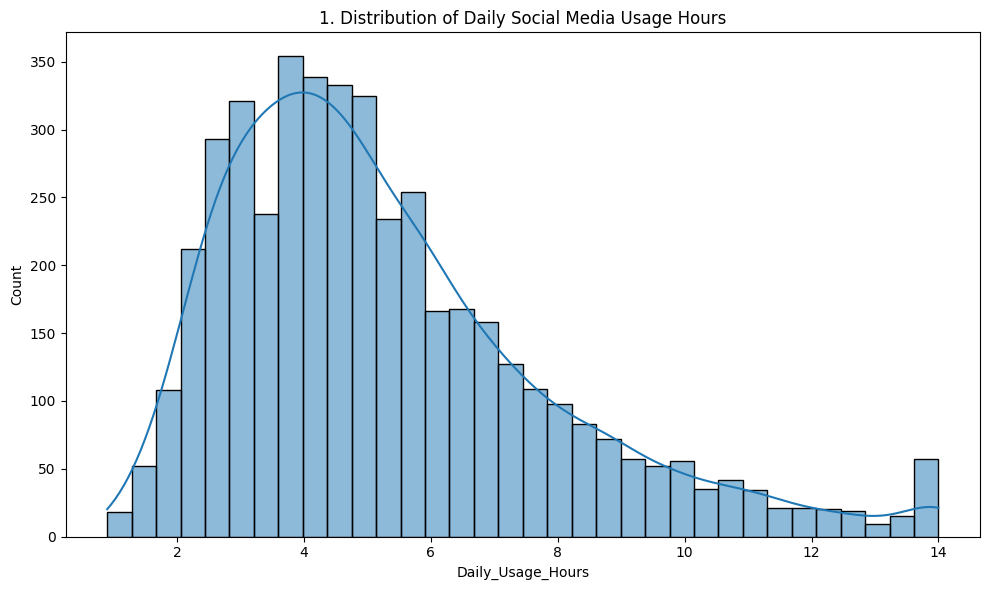

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Daily_Usage_Hours', kde=True)
plt.title(f'{plot_no}. Distribution of Daily Social Media Usage Hours')
show_fig()
plot_no += 1

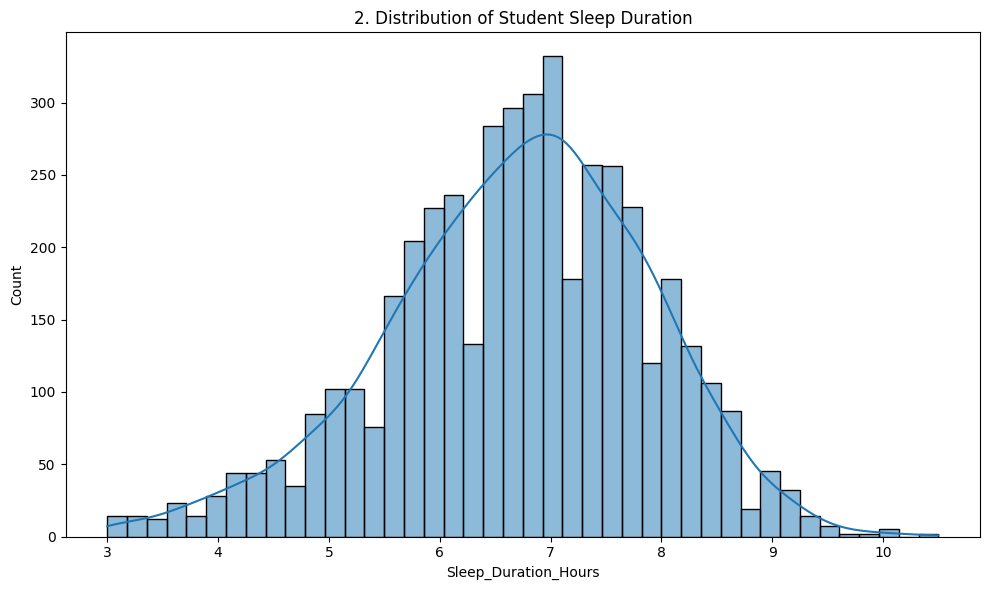

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Sleep_Duration_Hours', kde=True)
plt.title(f'{plot_no}. Distribution of Student Sleep Duration')
show_fig()
plot_no += 1

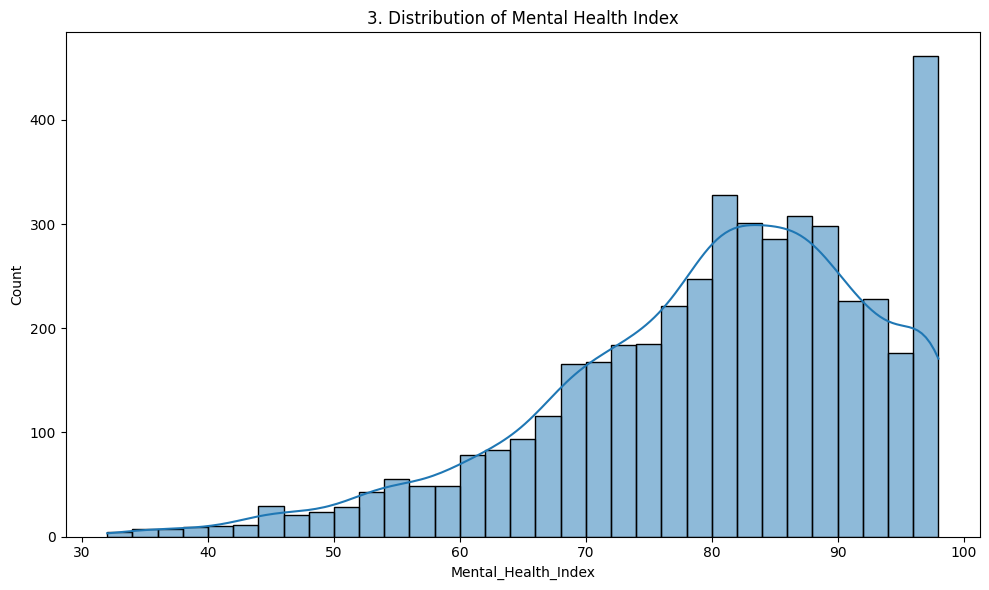

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Mental_Health_Index', kde=True)
plt.title(f'{plot_no}. Distribution of Mental Health Index')
show_fig()
plot_no += 1

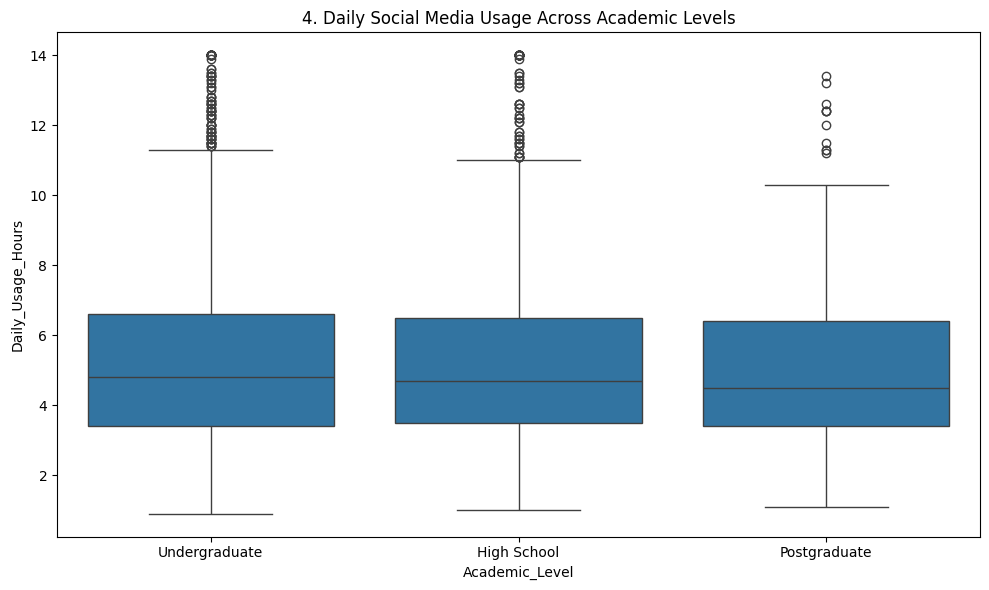

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Academic_Level', y='Daily_Usage_Hours')
plt.title(f'{plot_no}. Daily Social Media Usage Across Academic Levels')
show_fig()
plot_no += 1

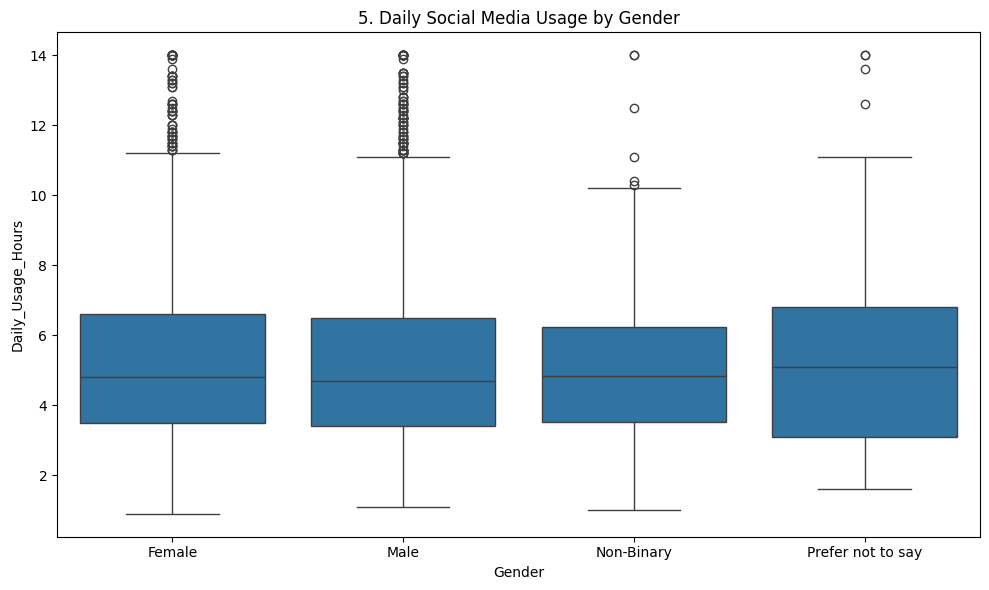

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Gender', y='Daily_Usage_Hours')
plt.title(f'{plot_no}. Daily Social Media Usage by Gender')
show_fig()
plot_no += 1

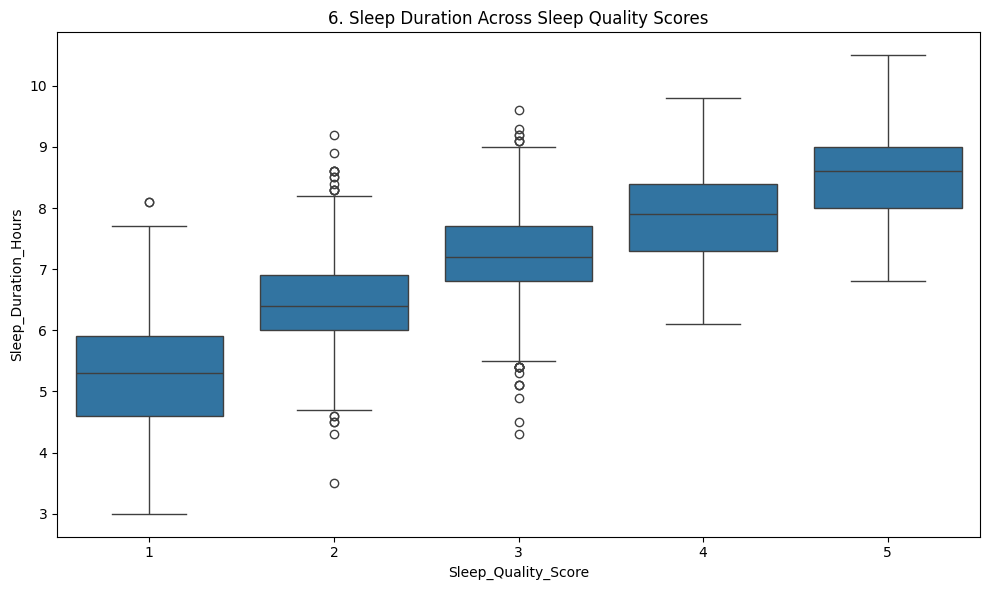

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Sleep_Quality_Score', y='Sleep_Duration_Hours')
plt.title(f'{plot_no}. Sleep Duration Across Sleep Quality Scores')
show_fig()
plot_no += 1

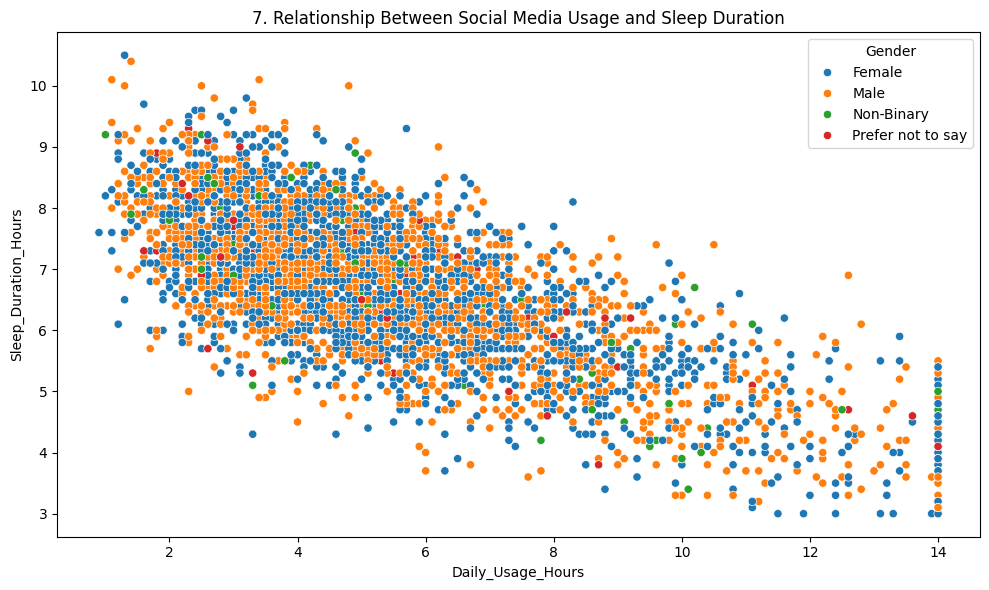

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Daily_Usage_Hours', y='Sleep_Duration_Hours', hue='Gender')
plt.title(f'{plot_no}. Relationship Between Social Media Usage and Sleep Duration')
show_fig()
plot_no += 1

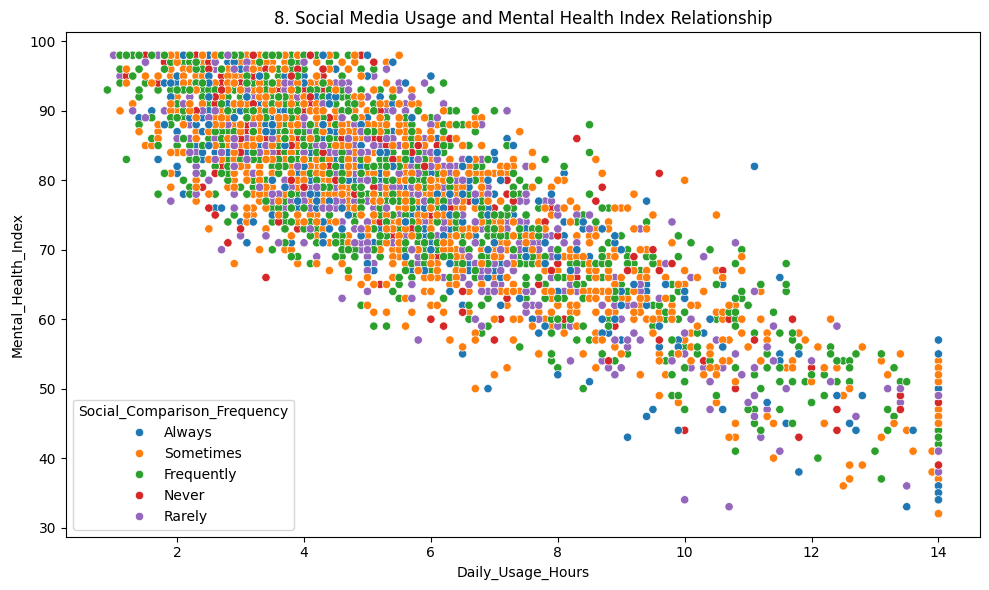

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Daily_Usage_Hours', y='Mental_Health_Index', hue='Social_Comparison_Frequency')
plt.title(f'{plot_no}. Social Media Usage and Mental Health Index Relationship')
show_fig()
plot_no += 1

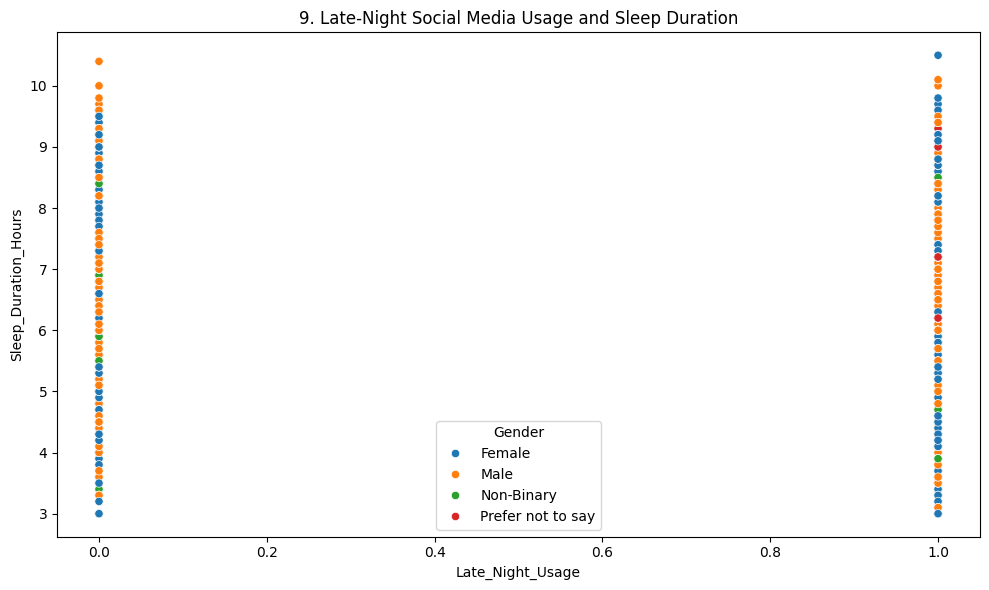

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Late_Night_Usage', y='Sleep_Duration_Hours', hue='Gender')
plt.title(f'{plot_no}. Late-Night Social Media Usage and Sleep Duration')
show_fig()
plot_no += 1

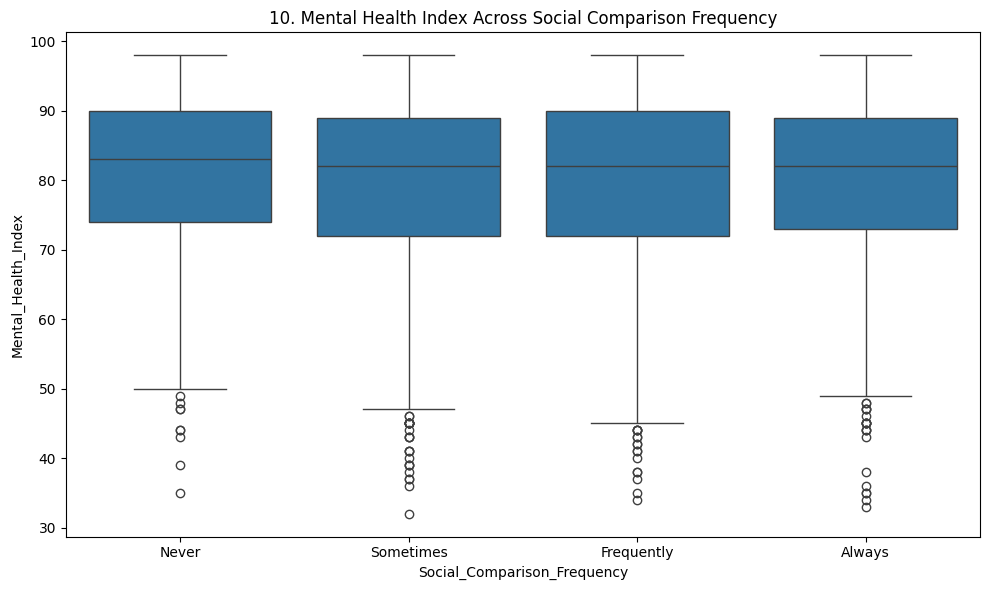

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Social_Comparison_Frequency', y='Mental_Health_Index', order=['Never', 'Sometimes', 'Frequently', 'Always'])
plt.title(f'{plot_no}. Mental Health Index Across Social Comparison Frequency')
show_fig()
plot_no += 1

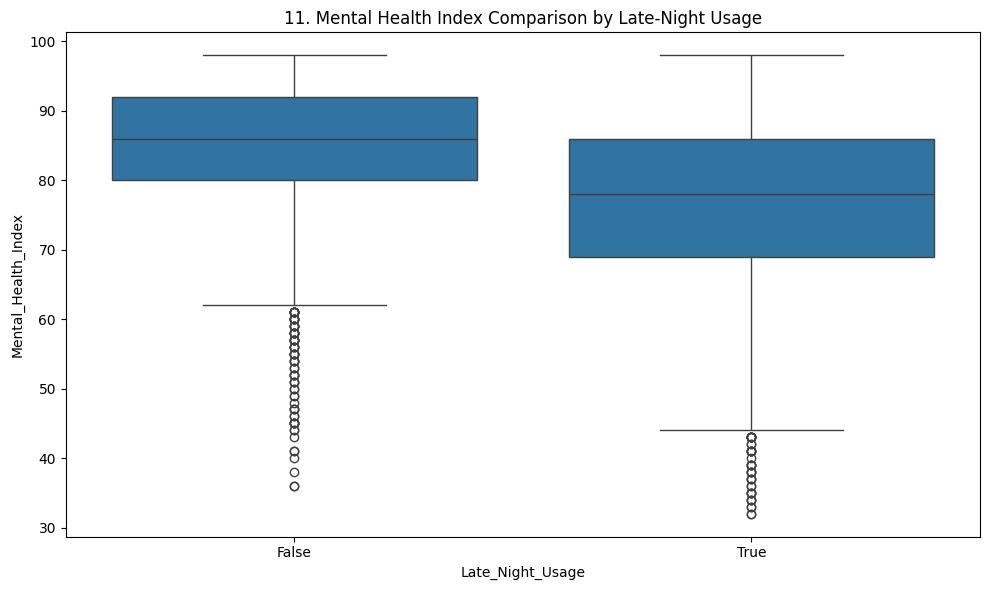

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Late_Night_Usage', y='Mental_Health_Index')
plt.title(f'{plot_no}. Mental Health Index Comparison by Late-Night Usage')
show_fig()
plot_no += 1

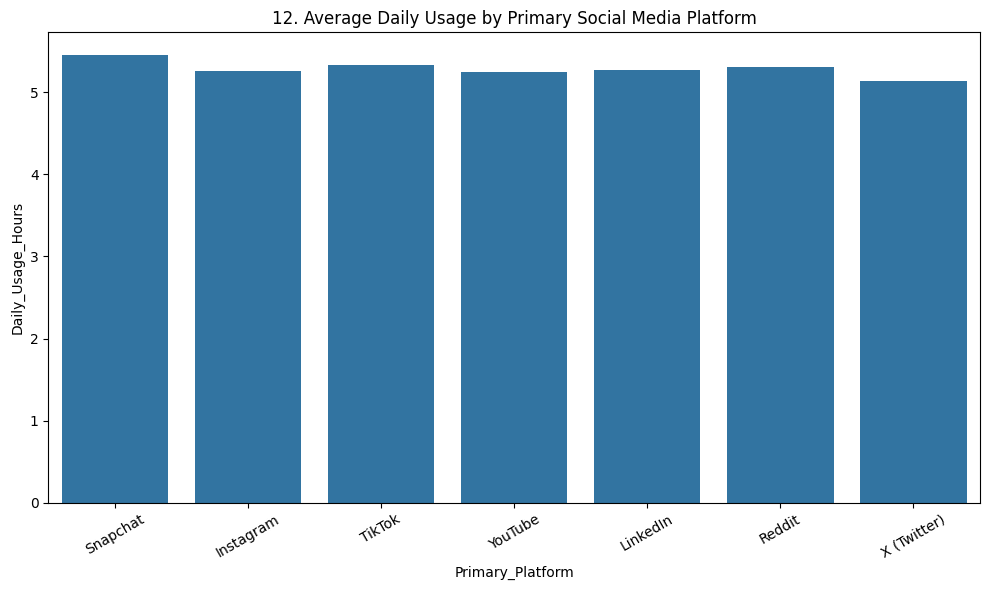

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Primary_Platform', y='Daily_Usage_Hours', estimator='mean', errorbar=None)
plt.xticks(rotation=30)
plt.title(f'{plot_no}. Average Daily Usage by Primary Social Media Platform')
show_fig()
plot_no += 1

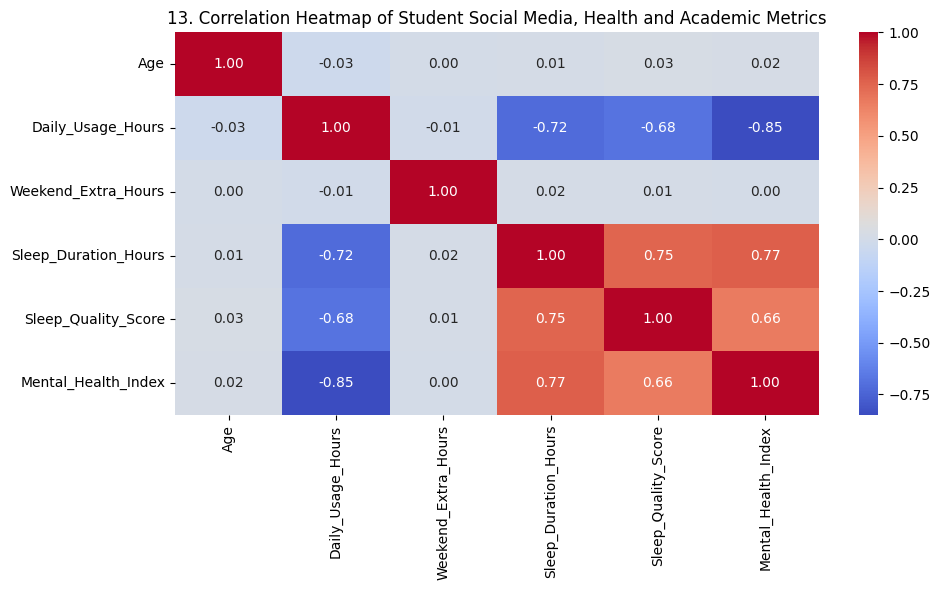

In [26]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Student Social Media, Health and Academic Metrics')
show_fig()
plot_no += 1

# Model Training

## Prepare features and binary target

In [27]:
data = df.copy()

data = data.drop(columns=['Student_ID'])

data['Late_Night_Usage'] = data['Late_Night_Usage'].astype(int)

data['Overall_Impact'] = data['Overall_Impact'].map({
    'Beneficial': 1,
    'Neutral': 0,
    'Harmful': 0
})

data = pd.get_dummies(
    data,
    columns=[
        'Gender',
        'Academic_Level',
        'Primary_Platform',
        'Device_Type',
        'Social_Comparison_Frequency'
    ],
    drop_first=True
)

data = data.apply(pd.to_numeric, errors='coerce')
data = data.dropna()

X = data.drop(columns=['Overall_Impact'])
y = data['Overall_Impact'].astype(int)

## Split the dataset

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Scale numerical features

In [29]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Build the deep learning model

In [30]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Train the deep learning model

In [31]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8068 - loss: 0.4210 - val_accuracy: 0.9153 - val_loss: 0.2553
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9324 - loss: 0.2113 - val_accuracy: 0.9376 - val_loss: 0.1663
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9465 - loss: 0.1493 - val_accuracy: 0.9495 - val_loss: 0.1206
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9577 - loss: 0.1151 - val_accuracy: 0.9643 - val_loss: 0.0945
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9636 - loss: 0.0966 - val_accuracy: 0.9643 - val_loss: 0.0800
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9673 - loss: 0.0797 - val_accuracy: 0.9747 - val_loss: 0.0680
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9695 - loss: 0.0771 - val_accuracy: 0.9747 - val_loss: 0.0625
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9729 - loss: 0.0683 - val_accuracy: 0.9762 - val_loss:

## Calculate model accuracy

In [32]:
y_prob = model.predict(X_test)
y_pred = (y_prob >= 0.5).astype(int).ravel()

accuracy = accuracy_score(y_test, y_pred)

print(f'Model Accuracy: {accuracy:.4f}')

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Model Accuracy: 0.9822


## Plot the confusion matrix

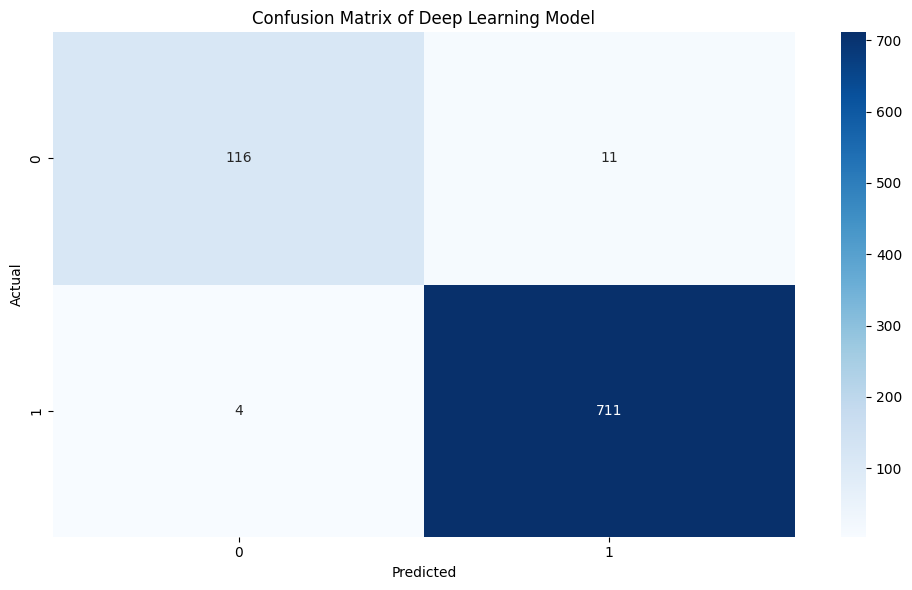

In [33]:
fig = plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Deep Learning Model')
show_fig()
plot_no += 1